In [9]:
pip install nbformat

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from lifelines import KaplanMeierFitter


In [11]:
df = pd.read_csv(r'C:\Users\CCLeyton\Documents\cancer_survival_app\app\data\BreastCancerMETABRIC.csv')

print(df.shape)
print(df.columns.tolist())

(2509, 34)
['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage', "Patient's Vital Status"]


In [12]:
print(df.isnull().sum())

Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
Radio Therap

In [13]:
# Drop rows where survival data is missing
df_survival = df.dropna(subset=['Overall Survival (Months)', 'Overall Survival Status'])

# Check how many patients remain
print(f'Patients remaining: {len(df_survival)}')

# Check what Overall Survival Status looks like
print(df_survival['Overall Survival Status'].value_counts())

Patients remaining: 1981
Overall Survival Status
Deceased    1144
Living       837
Name: count, dtype: int64


Text(0.5, 0.98, 'Overall Survival - METABRIC Breast Cancer Dataset')

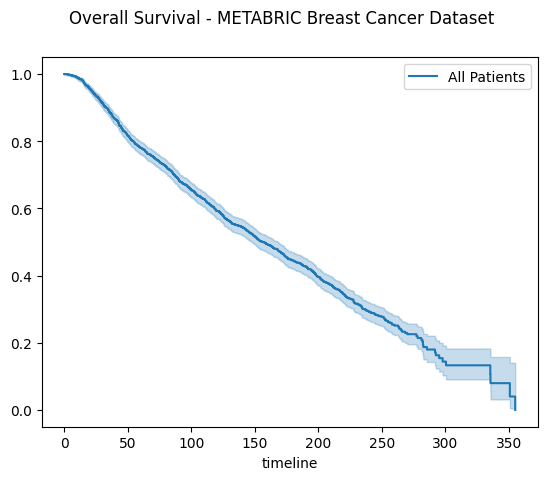

In [14]:
# Convert survival status to binary
df_survival = df_survival.copy()
df_survival['deceased'] = (df_survival['Overall Survival Status'] == 'Deceased').astype(int)

# Plot the first Kaplan-Meier curve
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df_survival['Overall Survival (Months)'],
    event_observed=df_survival['deceased'],
    label='All Patients'
)

fig = kmf.plot_survival_function()
fig.figure.suptitle('Overall Survival - METABRIC Breast Cancer Dataset')

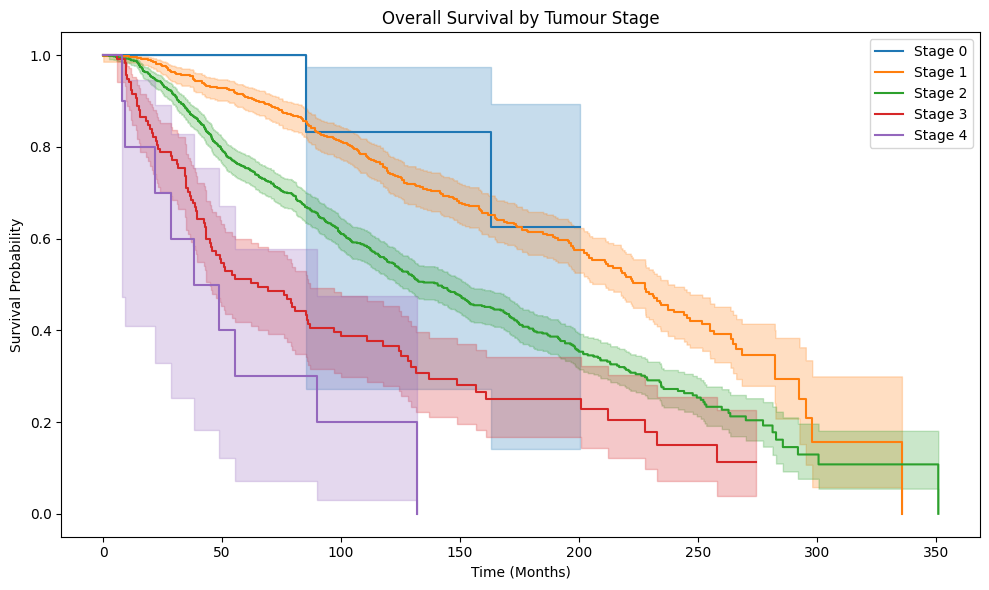

In [15]:
# Kaplan-Meier by Tumour Stage
df_stage = df_survival.dropna(subset=['Tumor Stage'])

fig, ax = plt.subplots(figsize=(10, 6))

for stage in sorted(df_stage['Tumor Stage'].unique()):
    mask = df_stage['Tumor Stage'] == stage
    kmf.fit(
        durations=df_stage.loc[mask, 'Overall Survival (Months)'],
        event_observed=df_stage.loc[mask, 'deceased'],
        label=f'Stage {int(stage)}'
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title('Overall Survival by Tumour Stage')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.show()

In [16]:
fig = go.Figure()

for stage in sorted(df_stage['Tumor Stage'].unique()):
    mask = df_stage['Tumor Stage'] == stage
    kmf.fit(
        durations=df_stage.loc[mask, 'Overall Survival (Months)'],
        event_observed=df_stage.loc[mask, 'deceased'],
        label=f'Stage {int(stage)}'
    )
    
    sf = kmf.survival_function_
    fig.add_trace(go.Scatter(
        x=sf.index,
        y=sf.iloc[:, 0],
        mode='lines',
        name=f'Stage {int(stage)}'
    ))

fig.update_layout(
    title='Overall Survival by Tumour Stage',
    xaxis_title='Time (Months)',
    yaxis_title='Survival Probability',
    hovermode='x unified'
)

fig.show()